# iQuHack 2026 - Quantum Entanglement Distillation Game

In this game, you design quantum circuits to distill noisy Bell pairs and claim edges in a network.

**Game Flow**: Register -> Select Starting Node -> Design Circuits -> Claim Edges -> Score Points

In [1]:
from client import GameClient
from visualization import GraphTool
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import json
from pathlib import Path

## Session Management

Save/load your session to avoid re-registering.

In [2]:
SESSION_FILE = Path("session.json")

def save_session(client):
    if client.api_token:
        with open(SESSION_FILE, "w") as f:
            json.dump({"api_token": client.api_token, "player_id": client.player_id, "name": client.name}, f)
        print(f"Session saved.")

def load_session():
    if not SESSION_FILE.exists():
        return None
    with open(SESSION_FILE) as f:
        data = json.load(f)
    client = GameClient(api_token=data.get("api_token"))
    client.player_id = data.get("player_id")
    client.name = data.get("name")
    status = client.get_status()
    if status:
        print(f"Resumed: {client.player_id} | Score: {status.get('score', 0)} | Budget: {status.get('budget', 0)}")
        return client
    return None

In [3]:
# Try to resume existing session
client = load_session()

if not client:
    print("No saved session. Register below.")

Resumed: 121234382 | Score: 89 | Budget: 1


## Step 1: Register

Skip this if you resumed a session above.

In [4]:
if client and client.api_token:
    print(f"Already registered as {client.player_id}")
else:
    client = GameClient()
    
    # CHANGE THESE to your unique values
    PLAYER_ID = "121234382"
    PLAYER_NAME = "tutum1"
    
    result = client.register(PLAYER_ID, PLAYER_NAME, location=input("remote or in_person: ").strip())
    
    if result.get("ok"):
        print(f"Registered! Token: {client.api_token[:20]}...")
        candidates = result["data"].get("starting_candidates", [])
        print(f"\nStarting candidates ({len(candidates)}):")
        for c in candidates:
            print(f"  - {c['node_id']}: {c['utility_qubits']} qubits, +{c['bonus_bell_pairs']} bonus")
        save_session(client)
    else:
        print(f"Failed: {result.get('error', {}).get('message')}")

Already registered as 121234382


## Step 2: Select Starting Node

In [5]:
status = client.get_status()

if status.get('starting_node'):
    print(f"Starting node: {status['starting_node']}")
    print(f"Budget: {status['budget']} | Score: {status['score']}")
else:
    print("Select a starting node from the candidates shown above.")
    # Uncomment and modify:
    result = client.select_starting_node("Aachen, Germany")
    print(result)

Starting node: Aachen, Germany
Budget: 1 | Score: 89


## Step 3: Explore the Network

In [6]:
client.print_status()

Player: 121234382 (tutum1)
Score: 89 | Budget: 1 bell pairs
Active: Yes
Starting node: Aachen, Germany
Owned: 43 nodes, 85 edges
Claimable edges: 53
  - ['Basel, Switzerland', 'Bern, Switzerland']: threshold=0.90, difficulty=1
  - ['Geneva, Switzerland', 'Lyon, France']: threshold=0.90, difficulty=1
  - ['Geneva, Switzerland', 'Grenoble, France']: threshold=0.90, difficulty=1
  ... and 50 more


(['London, UK',
  'Heidelberg, Germany',
  'Zurich, Switzerland',
  'Birmingham, UK',
  'Newcastle, UK',
  'Edinburgh, UK',
  'Copenhagen, Denmark',
  'Geneva, Switzerland',
  'Rotterdam, Netherlands',
  'Dusseldorf, Germany',
  'Strasbourg, France',
  'Lund, Sweden',
  'Leiden, Netherlands',
  'Oxford, UK',
  'Lille, France',
  'Luxembourg City',
  'Frankfurt, Germany',
  'Leeds, UK',
  'Bonn, Germany',
  'Sheffield, UK',
  'Brussels, Belgium',
  'Amsterdam, Netherlands',
  'Essen, Germany',
  'Bristol, UK',
  'Cambridge, UK',
  'Nuremberg, Germany',
  'Munich, Germany',
  'Eindhoven, Netherlands',
  'Stuttgart, Germany',
  'Basel, Switzerland',
  'Utrecht, Netherlands',
  'Lausanne, Switzerland',
  'Paris, France',
  'Antwerp, Belgium',
  'Manchester, UK',
  'Glasgow, UK',
  'Liverpool, UK',
  'Cardiff, UK',
  'Cologne, Germany',
  'Aachen, Germany',
  'Delft, Netherlands',
  'Leuven, Belgium',
  'Dortmund, Germany'],
 [['Aachen, Germany', 'Eindhoven, Netherlands'],
  ['Aachen, Germa

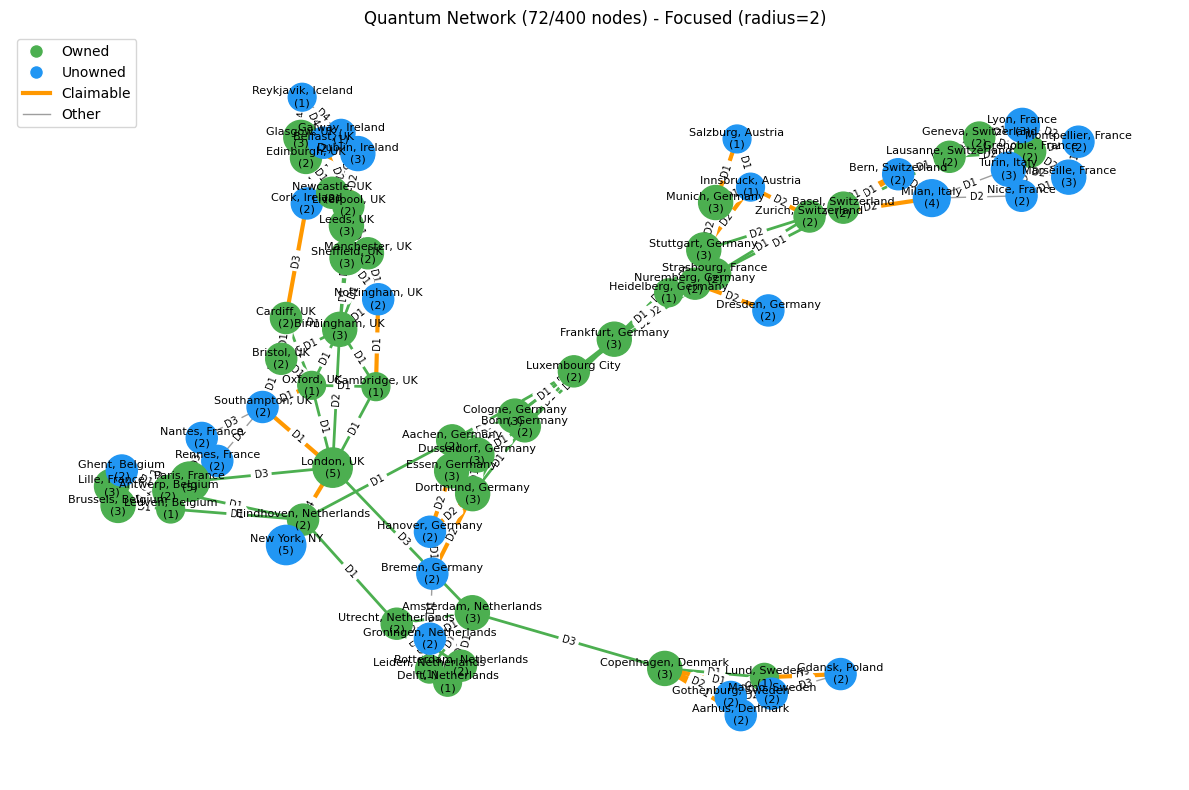

In [7]:
# Visualize the network (focused around your nodes)
viz = GraphTool(client.get_cached_graph())
owned = set(client.get_status().get('owned_nodes', []))
viz.render(owned)

## Step 4: Design a Distillation Circuit

For N Bell pairs, qubits are paired outside-in:
- Pair 0: qubits {0, 2N-1}
- Pair 1: qubits {1, 2N-2}
- ...
- Final pair: qubits {N-1, N}

Design a circuit that improves fidelity through LOCC operations.

In [8]:
from qiskit.circuit.classical import expr
import numpy as np
##### DEJMPS protocol 2 rounds
def create_distillation_circuit():
    """Example distillation circuit template for 2 Bell pairs."""
    qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.h(qr[1])
    qc.h(qr[2])
    qc.h(qr[3])

    qc.rx(np.pi/2, qr[0])
    qc.rx(np.pi/2, qr[1])

    qc.rx(-np.pi/2, qr[2])
    qc.rx(-np.pi/2, qr[3])

    qc.cx(qr[1],qr[0])
    qc.cx(qr[2],qr[3])

    qc.h(qr[0])
    qc.h(qr[1])
    qc.h(qr[2])
    qc.h(qr[3])

    qc.rx(np.pi/2, qr[0])
    qc.rx(np.pi/2, qr[1])

    qc.rx(-np.pi/2, qr[2])
    qc.rx(-np.pi/2, qr[3])

    qc.cx(qr[1],qr[0])
    qc.cx(qr[2],qr[3])

    qc.measure(qr[0],cr[0])
    qc.measure(qr[3],cr[1])

    qc.store(cr[2], expr.bit_xor(cr[0], cr[1]))

    return qc

circuit = create_distillation_circuit()
print(circuit.draw(output='text'))

     ┌───┐┌─────────┐ ┌───┐┌───┐┌─────────┐ ┌───┐┌─┐   
q_0: ┤ H ├┤ Rx(π/2) ├─┤ X ├┤ H ├┤ Rx(π/2) ├─┤ X ├┤M├───
     ├───┤├─────────┤ └─┬─┘├───┤├─────────┤ └─┬─┘└╥┘   
q_1: ┤ H ├┤ Rx(π/2) ├───■──┤ H ├┤ Rx(π/2) ├───■───╫────
     ├───┤├─────────┴┐     ├───┤├─────────┴┐      ║    
q_2: ┤ H ├┤ Rx(-π/2) ├──■──┤ H ├┤ Rx(-π/2) ├──■───╫────
     ├───┤├──────────┤┌─┴─┐├───┤├──────────┤┌─┴─┐ ║ ┌─┐
q_3: ┤ H ├┤ Rx(-π/2) ├┤ X ├┤ H ├┤ Rx(-π/2) ├┤ X ├─╫─┤M├
     └───┘└──────────┘└───┘└───┘└──────────┘└───┘ ║ └╥┘
c: 3/═════════════════════════════════════════════╩══╩═
                                                  0  1 


## Step 5: Claim an Edge

In [9]:
# Find claimable edges
claimable = client.get_claimable_edges()
claimable_sorted = sorted(claimable, key=lambda e: (e['difficulty_rating'], e['base_threshold']))

print(f"Claimable edges ({len(claimable)}):")
for edge in claimable_sorted:
    print(f"  {edge['edge_id']} - threshold: {edge['base_threshold']:.3f}, difficulty: {edge['difficulty_rating']}")

Claimable edges (56):
  ['Basel, Switzerland', 'Bern, Switzerland'] - threshold: 0.900, difficulty: 1
  ['Geneva, Switzerland', 'Lyon, France'] - threshold: 0.900, difficulty: 1
  ['Bern, Switzerland', 'Geneva, Switzerland'] - threshold: 0.900, difficulty: 1
  ['Bern, Switzerland', 'Zurich, Switzerland'] - threshold: 0.900, difficulty: 1
  ['Oxford, UK', 'Southampton, UK'] - threshold: 0.900, difficulty: 1
  ['London, UK', 'Southampton, UK'] - threshold: 0.900, difficulty: 1
  ['Manchester, UK', 'Nottingham, UK'] - threshold: 0.900, difficulty: 1
  ['Grenoble, France', 'Lyon, France'] - threshold: 0.900, difficulty: 1
  ['Innsbruck, Austria', 'Munich, Germany'] - threshold: 0.900, difficulty: 1
  ['Munich, Germany', 'Salzburg, Austria'] - threshold: 0.900, difficulty: 1
  ['Brussels, Belgium', 'Ghent, Belgium'] - threshold: 0.900, difficulty: 1
  ['Copenhagen, Denmark', 'Malmo, Sweden'] - threshold: 0.900, difficulty: 1
  ['Aarhus, Denmark', 'Copenhagen, Denmark'] - threshold: 0.900, d

In [10]:
def get_candidates_nodes():
    claimable = client.get_claimable_edges()
    claimable_sorted = sorted(claimable, key=lambda e: (e['difficulty_rating'], e['base_threshold']))
    
    owned_nodes, owned_edges = client.print_status()
    
    reachable_nodes = []
    for edge in claimable_sorted:
        if edge['edge_id'][0] in owned_nodes:
            reachable_nodes.append(edge['edge_id'][1])
        if edge['edge_id'][1] in owned_nodes:
            reachable_nodes.append(edge['edge_id'][0])
    
    graph_full_dict = client.get_cached_graph()
    sorted_nodes = sorted(graph_full_dict['nodes'], key=lambda n: (n["bonus_bell_pairs"], n["utility_qubits"]), reverse=True)
    
    candidates_nodes = []
    for node in sorted_nodes:
        if node['node_id'] in reachable_nodes:
            candidates_nodes.append(node)
            
    return candidates_nodes

In [11]:
def get_target_edge(target_node):
    target_edge = None
    claimable = client.get_claimable_edges()
    claimable_sorted = sorted(claimable, key=lambda e: (e['difficulty_rating'], e['base_threshold']))
    
    for edge in claimable_sorted:
        if (edge['edge_id'][0] == target_node['node_id']) or (edge['edge_id'][1] == target_node['node_id']):
            target_edge = edge
            break
    return target_edge

In [12]:
def get_node_by_name(node_name):
    graph_full_dict = client.get_cached_graph()
    for node in graph_full_dict['nodes']:
        if node['node_id'] == node_name:
            return node
    return None

In [14]:
def get_neighbours(node_id):
    neighbours = []
    graph_full_dict = client.get_cached_graph()
    owned_nodes, owned_edges = client.print_status()
    for edge in graph_full_dict['edges']:
        if edge['edge_id'][0] == node_id and edge['edge_id'][1] not in owned_nodes:
            neighbours.append(get_node_by_name(edge['edge_id'][1]))
        elif edge['edge_id'][1] == node_id and edge['edge_id'][0] not in owned_nodes:
            neighbours.append(get_node_by_name(edge['edge_id'][0]))
    return neighbours

get_neighbours("Birmingham, UK")

Player: 121234382 (tutum1)
Score: 89 | Budget: 1 bell pairs
Active: Yes
Starting node: Aachen, Germany
Owned: 43 nodes, 85 edges
Claimable edges: 53
  - ['Basel, Switzerland', 'Bern, Switzerland']: threshold=0.90, difficulty=1
  - ['Geneva, Switzerland', 'Lyon, France']: threshold=0.90, difficulty=1
  - ['Geneva, Switzerland', 'Grenoble, France']: threshold=0.90, difficulty=1
  ... and 50 more


[{'node_id': 'Nottingham, UK',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 5}]

In [15]:
def get_edge(node_a, node_b):
    graph_full_dict = client.get_cached_graph()
    for edge in graph_full_dict['edges']:
        if (edge['edge_id'][0] == node_a and edge['edge_id'][1] == node_b) or (edge['edge_id'][1] == node_a and edge['edge_id'][0] == node_b):
            return edge
    return None

node_a = "London, UK"
node_b = "Paris, France"
get_edge(node_a, node_b)

{'edge_id': ['London, UK', 'Paris, France'],
 'base_threshold': 0.9,
 'difficulty_rating': 3,
 'successful_attempts': 10}

In [16]:
def reachable_nodes_with_constrains(min_bonus=1, min_utility=0, max_difficulty=5):
    claimable = client.get_claimable_edges()
    claimable_sorted = sorted(claimable, key=lambda e: (e['difficulty_rating'], e['base_threshold']))
    
    owned_nodes, owned_edges = client.print_status()
    
    reachable_nodes = []
    for edge in claimable_sorted:
        if edge['edge_id'][0] in owned_nodes:
            reachable_nodes.append(edge['edge_id'][1])
        if edge['edge_id'][1] in owned_nodes:
            reachable_nodes.append(edge['edge_id'][0])
    
    graph_full_dict = client.get_cached_graph()
    sorted_nodes = sorted(graph_full_dict['nodes'], key=lambda n: (n["bonus_bell_pairs"], n["utility_qubits"]), reverse=True)
    
    candidates_nodes = []
    for node in sorted_nodes:
        if (node['node_id'] in reachable_nodes and 
            node['bonus_bell_pairs'] >= min_bonus and 
            node['utility_qubits'] >= min_utility):
            # Check difficulty
            target_edge = get_target_edge(node)
            if target_edge and target_edge['difficulty_rating'] <= max_difficulty:
                candidates_nodes.append(node)
    
    print(f"Reachable nodes with constrains ({len(candidates_nodes)}):")
    for node in candidates_nodes:
        print(f"  {node['node_id']} - bonus bell pairs: {node['bonus_bell_pairs']}, utility qubits: {node['utility_qubits']}")
        
    candidates_nodes = sorted(candidates_nodes, key=lambda n: (n["bonus_bell_pairs"], n["capacity"], n["utility_qubits"]), reverse=True)
    return candidates_nodes

reachable_nodes_with_constrains(min_bonus=0, min_utility=2, max_difficulty=1)

Player: 121234382 (tutum1)
Score: 89 | Budget: 1 bell pairs
Active: Yes
Starting node: Aachen, Germany
Owned: 43 nodes, 85 edges
Claimable edges: 53
  - ['Basel, Switzerland', 'Bern, Switzerland']: threshold=0.90, difficulty=1
  - ['Geneva, Switzerland', 'Lyon, France']: threshold=0.90, difficulty=1
  - ['Geneva, Switzerland', 'Grenoble, France']: threshold=0.90, difficulty=1
  ... and 50 more
Reachable nodes with constrains (9):
  Grenoble, France - bonus bell pairs: 1, utility qubits: 2
  Lyon, France - bonus bell pairs: 0, utility qubits: 3
  Nottingham, UK - bonus bell pairs: 0, utility qubits: 2
  Southampton, UK - bonus bell pairs: 0, utility qubits: 2
  Ghent, Belgium - bonus bell pairs: 0, utility qubits: 2
  Groningen, Netherlands - bonus bell pairs: 0, utility qubits: 2
  Bern, Switzerland - bonus bell pairs: 0, utility qubits: 2
  Malmo, Sweden - bonus bell pairs: 0, utility qubits: 2
  Aarhus, Denmark - bonus bell pairs: 0, utility qubits: 2


[{'node_id': 'Grenoble, France',
  'utility_qubits': 2,
  'bonus_bell_pairs': 1,
  'capacity': 6},
 {'node_id': 'Lyon, France',
  'utility_qubits': 3,
  'bonus_bell_pairs': 0,
  'capacity': 7},
 {'node_id': 'Bern, Switzerland',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 6},
 {'node_id': 'Malmo, Sweden',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 6},
 {'node_id': 'Aarhus, Denmark',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 6},
 {'node_id': 'Nottingham, UK',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 5},
 {'node_id': 'Southampton, UK',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 5},
 {'node_id': 'Ghent, Belgium',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 5},
 {'node_id': 'Groningen, Netherlands',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 5}]

In [59]:
# while True:
# Claim an edge
if claimable:
    # target = claimable_sorted[-1]  # Easiest edge
    # target_node = get_candidates_nodes()[0]
    node_name = "Grenoble, France"
    target_node = get_node_by_name(node_name)
    target = get_target_edge(target_node)
    # target = get_edge("London, UK", "Paris, France")
    edge_id = tuple(target['edge_id'])
    
    circuit = create_distillation_circuit()
    num_bell_pairs = 2
    flag_bit = 2  # Classical bit for post-selection (keep when flag=0)
    
    print(f"Claiming {edge_id} (threshold: {target['base_threshold']:.3f})...")
    
    # client.claim_edge(edge_id, circuit, flag_bit, num_bell_pairs)
    result = client.claim_edge(edge_id, circuit, flag_bit, num_bell_pairs)
    
    if result.get("ok"):
        data = result["data"]
        print(f"Success: {data.get('success')}")
        print(f"Fidelity: {data.get('fidelity', 0):.4f} (threshold: {data.get('threshold', 0):.4f})")
        print(f"Success probability: {data.get('success_probability', 0):.4f}")
    else:
        print(f"Error: {result.get('error', {}).get('message')}")
        
    owned_nodes = client.get_status().get('owned_nodes', [])
    if node_name in owned_nodes:
        print(f"Node {node_name} successfully owned!")
    else:
        print(f"Node {node_name} not owned yet.")

Claiming ('Geneva, Switzerland', 'Grenoble, France') (threshold: 0.900)...
Success: True
Fidelity: 0.9698 (threshold: 0.9000)
Success probability: 0.7450
Node Grenoble, France not owned yet.


## Step 6: Check Progress

In [17]:
owned_nodes, owned_edges = client.print_status()

Player: 121234382 (tutum1)
Score: 89 | Budget: 1 bell pairs
Active: Yes
Starting node: Aachen, Germany
Owned: 43 nodes, 85 edges
Claimable edges: 53
  - ['Basel, Switzerland', 'Bern, Switzerland']: threshold=0.90, difficulty=1
  - ['Geneva, Switzerland', 'Lyon, France']: threshold=0.90, difficulty=1
  - ['Geneva, Switzerland', 'Grenoble, France']: threshold=0.90, difficulty=1
  ... and 50 more


In [18]:
reachable_nodes = []
for edge in claimable_sorted:
    if edge['edge_id'][0] in owned_nodes:
        reachable_nodes.append(edge['edge_id'][1])
    if edge['edge_id'][1] in owned_nodes:
        reachable_nodes.append(edge['edge_id'][0])
reachable_nodes

['Bern, Switzerland',
 'Lyon, France',
 'Bern, Switzerland',
 'Bern, Switzerland',
 'Southampton, UK',
 'Southampton, UK',
 'Nottingham, UK',
 'Innsbruck, Austria',
 'Salzburg, Austria',
 'Ghent, Belgium',
 'Malmo, Sweden',
 'Aarhus, Denmark',
 'Nottingham, UK',
 'Southampton, UK',
 'Nottingham, UK',
 'Nottingham, UK',
 'Nottingham, UK',
 'Southampton, UK',
 'Ghent, Belgium',
 'Ghent, Belgium',
 'Ghent, Belgium',
 'Groningen, Netherlands',
 'Groningen, Netherlands',
 'Bern, Switzerland',
 'Malmo, Sweden',
 'Belfast, UK',
 'Dublin, Ireland',
 'Ghent, Belgium',
 'Lyon, France',
 'Gothenburg, Sweden',
 'Milan, Italy',
 'Belfast, UK',
 'Dresden, Germany',
 'Innsbruck, Austria',
 'Innsbruck, Austria',
 'Gothenburg, Sweden',
 'Turin, Italy',
 'Belfast, UK',
 'Rennes, France',
 'Hanover, Germany',
 'Hanover, Germany',
 'Bremen, Germany',
 'Groningen, Netherlands',
 'Aarhus, Denmark',
 'Gdansk, Poland',
 'Cork, Ireland',
 'Galway, Ireland',
 'Nantes, France',
 'Reykjavik, Iceland',
 'Reykjavik

In [19]:
graph_full_dict = client.get_cached_graph()
sorted_nodes = sorted(graph_full_dict['nodes'], key=lambda n: (n["bonus_bell_pairs"], n["utility_qubits"]), reverse=True)
sorted_nodes

[{'node_id': 'Chicago, IL',
  'utility_qubits': 5,
  'bonus_bell_pairs': 2,
  'capacity': 10},
 {'node_id': 'Tokyo, Japan',
  'utility_qubits': 5,
  'bonus_bell_pairs': 2,
  'capacity': 11},
 {'node_id': 'Beijing, China',
  'utility_qubits': 5,
  'bonus_bell_pairs': 2,
  'capacity': 10},
 {'node_id': 'Boston, MA',
  'utility_qubits': 4,
  'bonus_bell_pairs': 2,
  'capacity': 9},
 {'node_id': 'Vienna, Austria',
  'utility_qubits': 4,
  'bonus_bell_pairs': 2,
  'capacity': 8},
 {'node_id': 'Singapore',
  'utility_qubits': 4,
  'bonus_bell_pairs': 2,
  'capacity': 11},
 {'node_id': 'Munich, Germany',
  'utility_qubits': 3,
  'bonus_bell_pairs': 2,
  'capacity': 9},
 {'node_id': 'Tel Aviv, Israel',
  'utility_qubits': 3,
  'bonus_bell_pairs': 2,
  'capacity': 8},
 {'node_id': 'Zurich, Switzerland',
  'utility_qubits': 2,
  'bonus_bell_pairs': 2,
  'capacity': 9},
 {'node_id': 'Pasadena, CA',
  'utility_qubits': 2,
  'bonus_bell_pairs': 2,
  'capacity': 6},
 {'node_id': 'New Haven, CT',
  '

In [20]:
candidates_nodes = []
for node in sorted_nodes:
    if node['node_id'] in reachable_nodes:
        candidates_nodes.append(node)
candidates_nodes

[{'node_id': 'Innsbruck, Austria',
  'utility_qubits': 1,
  'bonus_bell_pairs': 2,
  'capacity': 5},
 {'node_id': 'New York, NY',
  'utility_qubits': 5,
  'bonus_bell_pairs': 1,
  'capacity': 11},
 {'node_id': 'Milan, Italy',
  'utility_qubits': 4,
  'bonus_bell_pairs': 0,
  'capacity': 9},
 {'node_id': 'Dublin, Ireland',
  'utility_qubits': 3,
  'bonus_bell_pairs': 0,
  'capacity': 8},
 {'node_id': 'Lyon, France',
  'utility_qubits': 3,
  'bonus_bell_pairs': 0,
  'capacity': 7},
 {'node_id': 'Turin, Italy',
  'utility_qubits': 3,
  'bonus_bell_pairs': 0,
  'capacity': 7},
 {'node_id': 'Dresden, Germany',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 5},
 {'node_id': 'Gothenburg, Sweden',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 6},
 {'node_id': 'Gdansk, Poland',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 5},
 {'node_id': 'Nottingham, UK',
  'utility_qubits': 2,
  'bonus_bell_pairs': 0,
  'capacity': 5},
 {'node_id': 'Belfast, UK'

In [21]:
target_node = candidates_nodes[0]
target_edge = None
for edge in claimable_sorted:
    if (edge['edge_id'][0] == target_node['node_id']) or (edge['edge_id'][1] == target_node['node_id']):
        target_edge = edge
        break
target_edge

{'edge_id': ['Innsbruck, Austria', 'Munich, Germany'],
 'base_threshold': 0.9,
 'difficulty_rating': 1,
 'successful_attempts': 8}

In [22]:
# View leaderboard
leaderboard = client.get_leaderboard()["leaderboard"]
print("Leaderboard:")
for i, p in enumerate(leaderboard[:10]):
    print(f"{i+1}. {p.get('player_id', 'Unknown'):20} Score: {p.get('score', 0)}")

Leaderboard:
1. Julio Cesar          Score: 100
2. GiselleRocio         Score: 98
3. diyamagnetism28      Score: 89
4. 121234382            Score: 89
5. bloch_single_run_v8  Score: 85
6. bloch                Score: 84
7. bloch_distiller      Score: 84
8. aquaman              Score: 71
9. test_claude_1523b    Score: 70
10. orion_the_first      Score: 69


## Tips

- **Failed attempts are free** - only successful claims cost bell pairs
- **More bell pairs** can improve fidelity but cost more budget
- **Vertex rewards** are competitive - top players by claim strength earn rewards
- **Budget management** is key - if budget reaches 0, you're eliminated

Good luck!

In [23]:
# Restart game (uncomment to use)
# result = client.restart()
# print(result)